In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

from utils.solver import Solver
from models.fuel_pin.fuel_pin_model import FuelPin

import data.dataclass as d_class

%config InlineBackend.figure_format = "retina"

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [3]:
def generate_cfg(data, N_R, N_Z):
    geom   = d_class.FuelPinGeometry(**data["geometry"])
    mesh   = d_class.FuelPinMesh(N_R=N_R, N_Z=N_Z)
    energy = d_class.FuelPinEnergy(**data["energy"])
    mat    = d_class.FuelPinMaterial(**data["material"])
    cfg = d_class.FuelPinConfig(geom, mesh, energy, mat)
    cfg = cfg.resolve_mesh()
    return cfg

In [4]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data_fp = data["FuelPin"]

cfg = generate_cfg(data_fp, 25, 50)

fuelpin = FuelPin(cfg)

In [5]:
def debug_fuel_mesh(cfg, fuel_pin):
    print("N_R    =", cfg.mesh.N_R)
    print("N_fuel =", cfg.mesh.N_fuel)
    print("N_gap  =", cfg.mesh.N_gap)
    print("N_wall =", cfg.mesh.N_wall)
    print("sum    =", cfg.mesh.N_fuel + cfg.mesh.N_gap + cfg.mesh.N_wall)

    fuel_pin.initialize_discretization()

    V = fuel_pin.Delta_V
    V_fuel = V[:cfg.mesh.N_fuel]

    print("Delta_V shape =", V.shape)
    print("V min/max     =", V.min(), V.max())
    print("V_fuel min/max =", V_fuel.min(), V_fuel.max())
    print(
        "V_fuel rel spread =",
        (V_fuel.max() - V_fuel.min()) / V_fuel.mean(),
    )

    print("R increasing =", np.all(np.diff(fuel_pin.R) > 0.0))
    print("delta_Rm positive =", np.all(fuel_pin.delta_Rm > 0.0))
    print("delta_Rp positive =", np.all(fuel_pin.delta_Rp > 0.0))

debug_fuel_mesh(cfg, fuelpin)

N_R    = 25
N_fuel = 21
N_gap  = 1
N_wall = 3
sum    = 25
Delta_V shape = (25,)
V min/max     = 1.1026990214100212e-07 2.412743157956957e-07
V_fuel min/max = 1.509759669525144e-07 1.5097596695251602e-07
V_fuel rel spread = 1.069479194798832e-14
R increasing = True
delta_Rm positive = True
delta_Rp positive = True


In [6]:
solver = Solver([fuelpin])
solver.fsolve()

fsolve message: The solution converged.


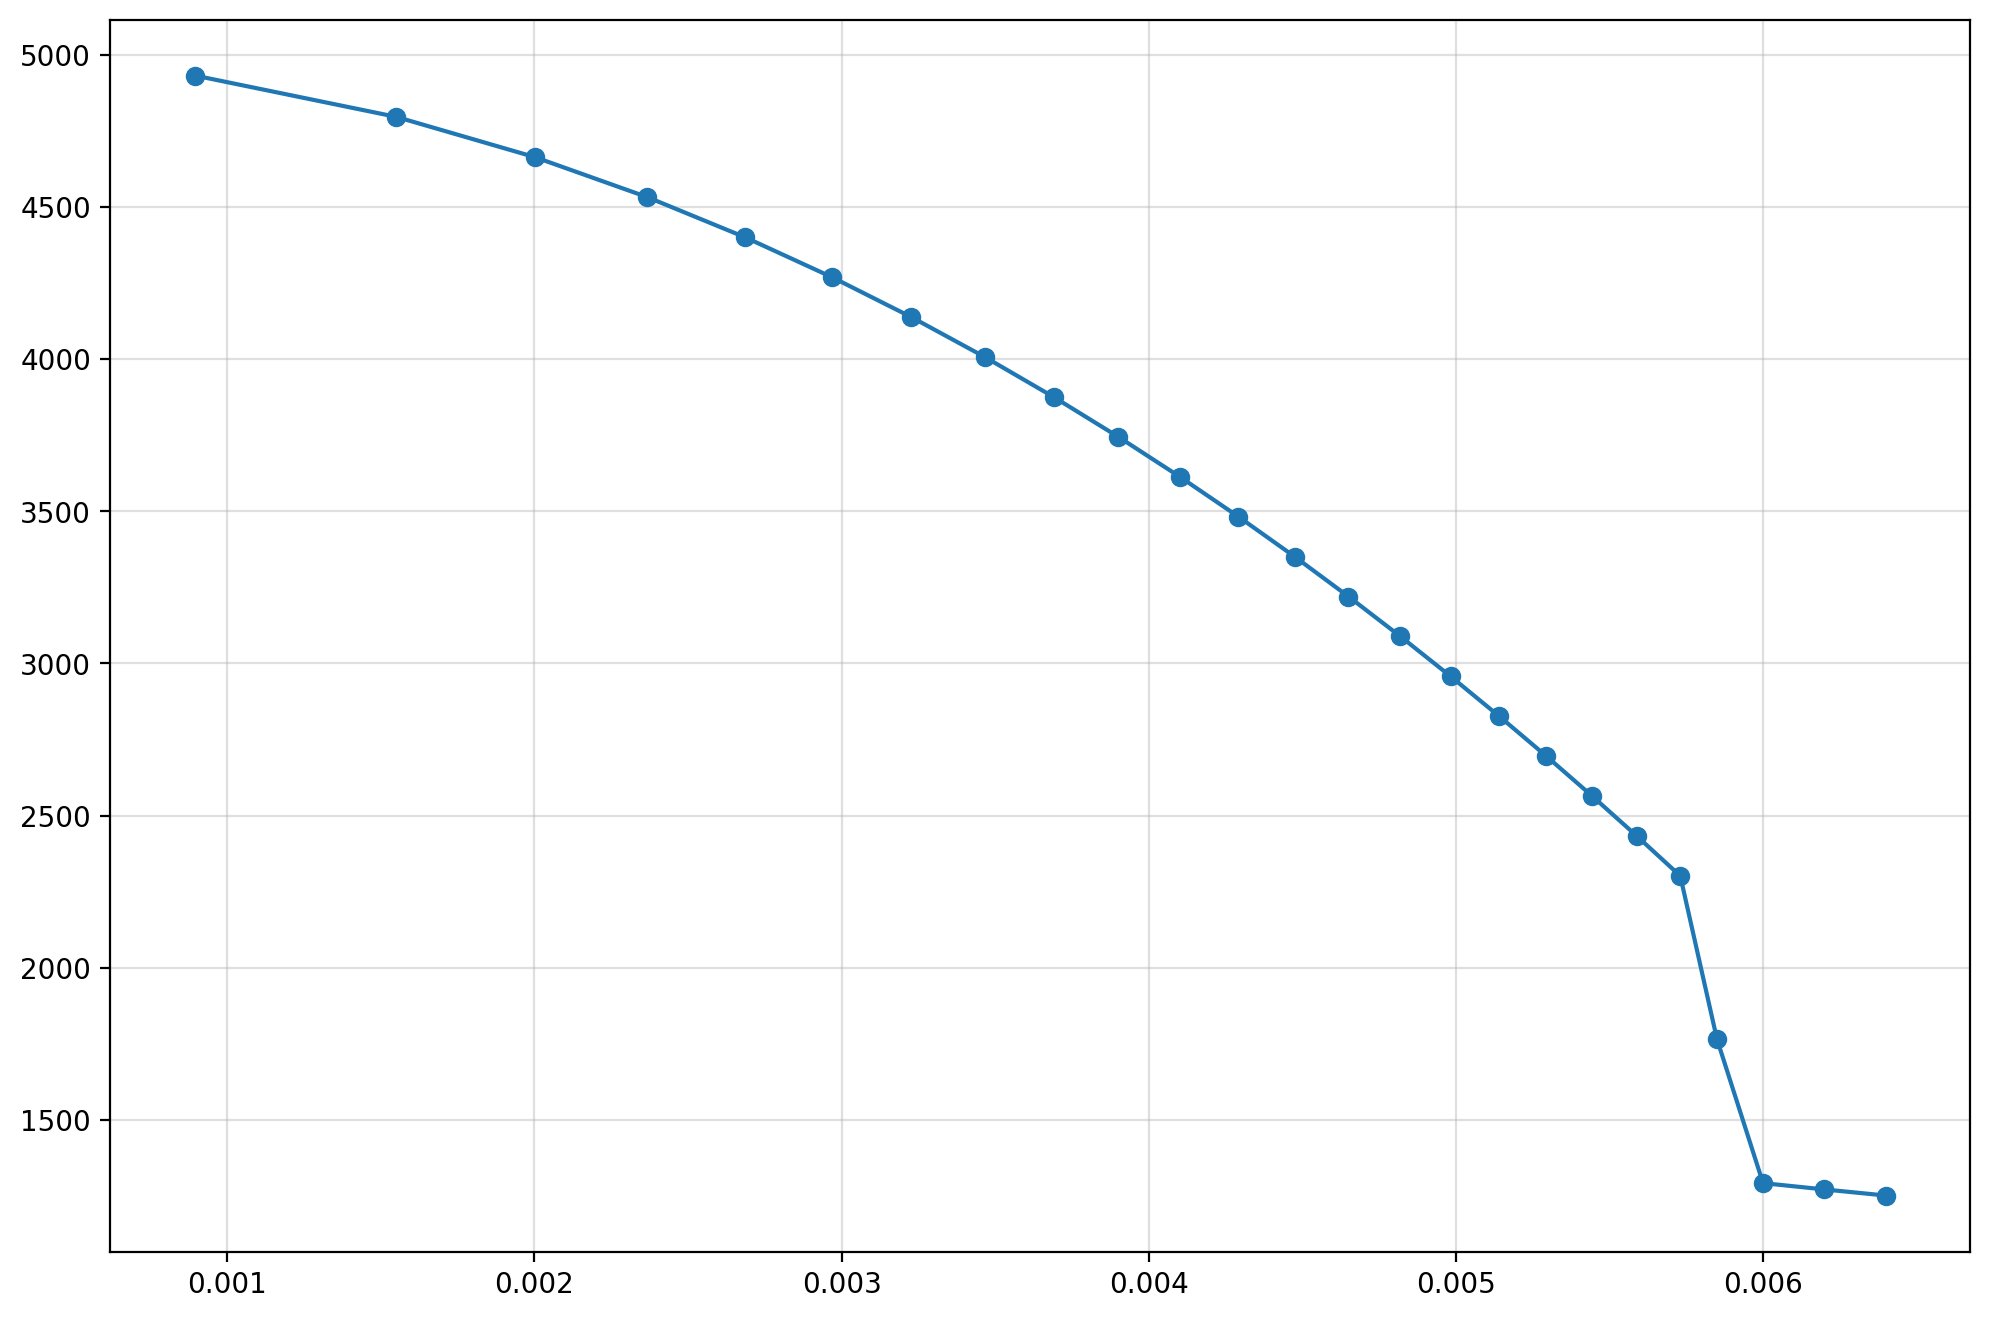

In [7]:
T_FP, = solver.solutions[0]
r = fuelpin.R

plt.figure(figsize=(12,8))
plt.plot(r, T_FP[0, :], "o-")
plt.grid(alpha=0.4)
plt.show()